/tmp/ipykernel_40189/612898127.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


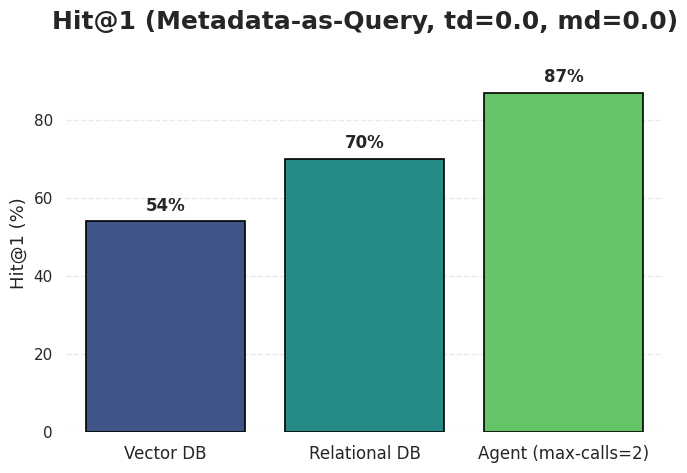

/tmp/ipykernel_40189/612898127.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


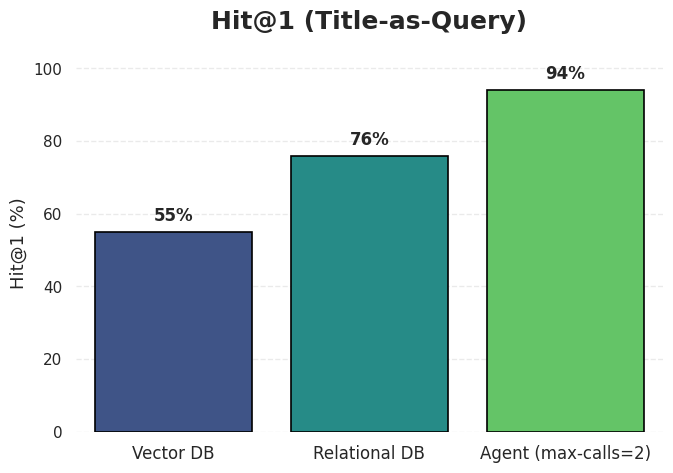

In [13]:
config = [
    {
        "data": "title_as_query",
        "name": "dense.para-abs",
        "display_name": "Vector DB",
        "hit@1": 55,
    },
    {
        "data": "title_as_query",
        "name": "relational.gpt-51.minimal",
        "display_name": "Relational DB",
        "hit@1": 76,
    },
    {
        "data": "title_as_query",
        "name": "agent.gpt-51.max-turns-3.para-abs",
        "display_name": "Agent (max-calls=2)",
        "hit@1": 94,
    },

    {
        "data": "metadata_as_query_td0.0_md0.0",
        "name": "dense.para-abs",
        "display_name": "Vector DB",
        "hit@1": 54,
    },
    {
        "data": "metadata_as_query_td0.0_md0.0",
        "name": "relational.gpt-51.minimal",
        "display_name": "Relational DB",
        "hit@1": 70,
    },
    {
        "data": "metadata_as_query_td0.0_md0.0",
        "name": "agent.gpt-51.max-turns-3.para-abs",
        "display_name": "Agent (max-calls=2)",
        "hit@1": 87,
    },
]

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create DataFrame
df = pd.DataFrame(config)

# General style
sns.set_theme(style="whitegrid", font_scale=1.3)

# Pretty color palette shared across plots
palette = sns.color_palette("viridis", n_colors=df["display_name"].nunique())

# Nice mapping from dataset id to title text
DATA_TITLES = {
    "title_as_query": "Hit@1 (Title-as-Query)",
    "metadata_as_query_td0.0_md0.0": "Hit@1 (Metadata-as-Query, td=0.0, md=0.0)",
}

for data_name, df_sub in df.groupby("data"):
    plt.figure(figsize=(7, 5))

    ax = sns.barplot(
        x="display_name",
        y="hit@1",
        data=df_sub,
        palette=palette,
        edgecolor="black",
        linewidth=1.2,
        saturation=0.9,
    )

    # Add value labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.0f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Titles and labels
    title = DATA_TITLES.get(data_name, data_name)
    ax.set_title(title, fontsize=18, pad=18, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Hit@1 (%)", fontsize=13)

    # Clean up spines and grid
    sns.despine(left=True, bottom=True)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Style ticks
    ax.tick_params(axis="x", labelsize=12)
    ax.tick_params(axis="y", labelsize=11)

    # Make y-axis start at 0 and leave a little headroom
    ymin, ymax = 0, max(df_sub["hit@1"]) + 10
    ax.set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()